## <span style="color:grey; font-weight:bold;">Import Tools and Def Functions</span>

In [15]:
import Def_Function
import pandas as pd
import os
import importlib
import matplotlib.pyplot as plt
import sys

sys.path.append('/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis')

In [16]:
importlib.reload(Def_Function)

from Def_Function import ReadandMergeAllChunk, DataFrameNormalizeScaler, ColumnsHist, CorrHeatMap
from Def_Function import PointBiserialandFilter, TestTrainSplit, SaveCSVNoChunk

In [17]:
pd.set_option('display.float_format', '{:.2f}'.format)

In [18]:
data_path = '/Users/porter/Desktop/01.Data Science/Porter - Project/05 - Advertising Challenge - Data Analysis/Data'
os.chdir(data_path)

## <span style="color:grey; font-weight:bold;">Feature</span>

#### <span style="color:grey; font-weight:bold;">Merge Chunk</span>

In [19]:
train_df = ReadandMergeAllChunk(5)

Data Preprocessing Chunk 1.csv is Loaded
Data Preprocessing Chunk 2.csv is Loaded
Data Preprocessing Chunk 3.csv is Loaded
Data Preprocessing Chunk 4.csv is Loaded
Data Preprocessing Chunk 5.csv is Loaded
All Chunk is Read and Merged



In [14]:
train_df.shape

(20945517, 38)

In [13]:
train_df.head(10)

,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
0,0.00,0.78,1.39,2.53,0.67,5.65,2.30,0.97,1.19,1.67,...,1207693,0,3397,265,0,719842,3,36054,78,37710
1,0.00,0.56,1.79,3.34,0.00,17.84,3.79,0.00,2.05,4.62,...,122474,5,213,265,0,1515269,3,109766,81,50721
2,0.00,0.00,4.01,2.77,1.48,11.75,3.53,0.64,1.82,2.31,...,263299,4,351,265,2,1858253,14,75814,78,64578
3,1.00,0.56,6.90,1.56,1.04,5.69,1.12,0.64,1.19,1.13,...,282304,8,1675,265,2,438551,2,94484,0,56025
4,0.00,0.00,3.33,1.34,1.04,10.65,2.70,1.56,2.88,4.92,...,75910,9,3397,265,2,1811968,2,40660,81,49152
5,0.00,0.00,1.61,2.75,0.00,10.45,6.36,0.64,1.82,4.21,...,139580,8,1738,1341,1,1643356,2,105687,78,57729
6,1.00,0.00,1.61,2.18,2.44,10.12,4.99,2.50,4.59,8.01,...,1178671,3,610,265,1,942846,2,82101,55,67784
7,1.00,0.00,4.88,0.64,1.29,10.27,3.18,2.30,3.61,7.13,...,438384,6,3639,2035,1,399239,13,33855,1,24013
8,0.00,1.09,1.10,1.56,1.48,9.17,4.01,2.30,4.64,4.75,...,476896,9,3623,265,1,835429,10,81119,0,23335
9,0.00,1.36,3.04,0.97,2.18,7.25,3.39,2.37,4.06,4.62,...,1097369,9,3623,2071,1,412319,4,65097,0,79482


In [12]:
train_df.tail(10)

,Predicted,1,2,3,4,5,6,7,8,9,...,29,30,31,32,33,34,36,37,38,39
20945507,0.00,0.56,4.30,2.44,2.44,3.52,1.43,2.57,3.94,4.96,...,2312727,9,1978,1803,2,5233095,2,71046,88,40926
20945508,0.00,0.56,4.29,1.19,1.04,11.20,3.76,0.00,2.24,2.05,...,702503,2,5384,274,0,2742777,11,141144,88,79639
20945509,0.00,0.00,1.61,1.35,1.29,7.70,8.19,0.65,2.24,4.61,...,1062255,8,482,274,0,6160536,4,195302,64,73982
20945510,1.00,1.10,1.10,1.66,1.04,6.60,2.30,3.07,3.80,4.23,...,3854284,6,684,2067,1,1851274,2,79130,0,113194
20945511,1.00,1.10,8.14,2.12,1.04,5.41,2.62,2.70,3.57,6.92,...,3885468,9,4092,235,1,190750,4,243650,1,8826
20945512,0.00,0.56,3.14,2.28,1.48,11.81,3.76,0.00,2.42,5.42,...,1062255,5,1616,274,0,6160536,2,195302,94,95444
20945513,1.00,1.16,1.39,2.51,2.72,4.89,4.46,1.76,5.21,4.36,...,3764091,4,1223,274,0,1924088,2,186317,0,26682
20945514,0.00,0.00,2.64,2.61,2.11,11.19,3.76,1.37,3.30,4.14,...,22053,8,2970,1372,1,1452853,13,55059,91,9997
20945515,0.00,0.56,0.69,1.57,1.48,16.58,3.95,0.65,0.00,4.14,...,5280080,4,2970,236,1,3633173,10,234052,88,5204
20945516,0.00,0.00,3.18,1.47,1.29,12.78,3.65,1.89,2.24,4.26,...,4230298,9,418,1778,0,2628787,3,26163,88,102619


In [15]:
train_df.iloc[:, 1:13].describe()

,1,2,3,4,5,6,7,8,9,10,11,13
count,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00,20945517.00
mean,0.55,2.54,1.76,1.54,10.22,3.65,1.28,2.57,4.00,0.67,0.70,1.52
std,0.36,1.72,0.65,0.69,5.10,1.74,0.89,1.54,1.85,0.53,0.46,0.70
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.56,1.39,1.35,1.04,6.73,2.70,0.64,1.53,2.81,0.00,0.59,1.03
50%,0.56,1.61,1.66,1.48,10.73,3.79,1.20,2.58,4.05,0.90,0.60,1.46
75%,0.56,3.56,2.25,1.97,13.35,4.59,1.95,3.82,5.20,1.00,1.03,1.99
max,1.50,12.46,4.08,4.78,36.03,16.28,4.13,5.71,12.96,11.00,2.06,4.94


In [16]:
train_df['Predicted'].value_counts() / train_df['Predicted'].shape[0]*100

Predicted
0.00   75.15
1.00   24.85
Name: count, dtype: float64

In [20]:
train_df = DataFrameNormalizeScaler(train_df, exclude_col='Predicted')

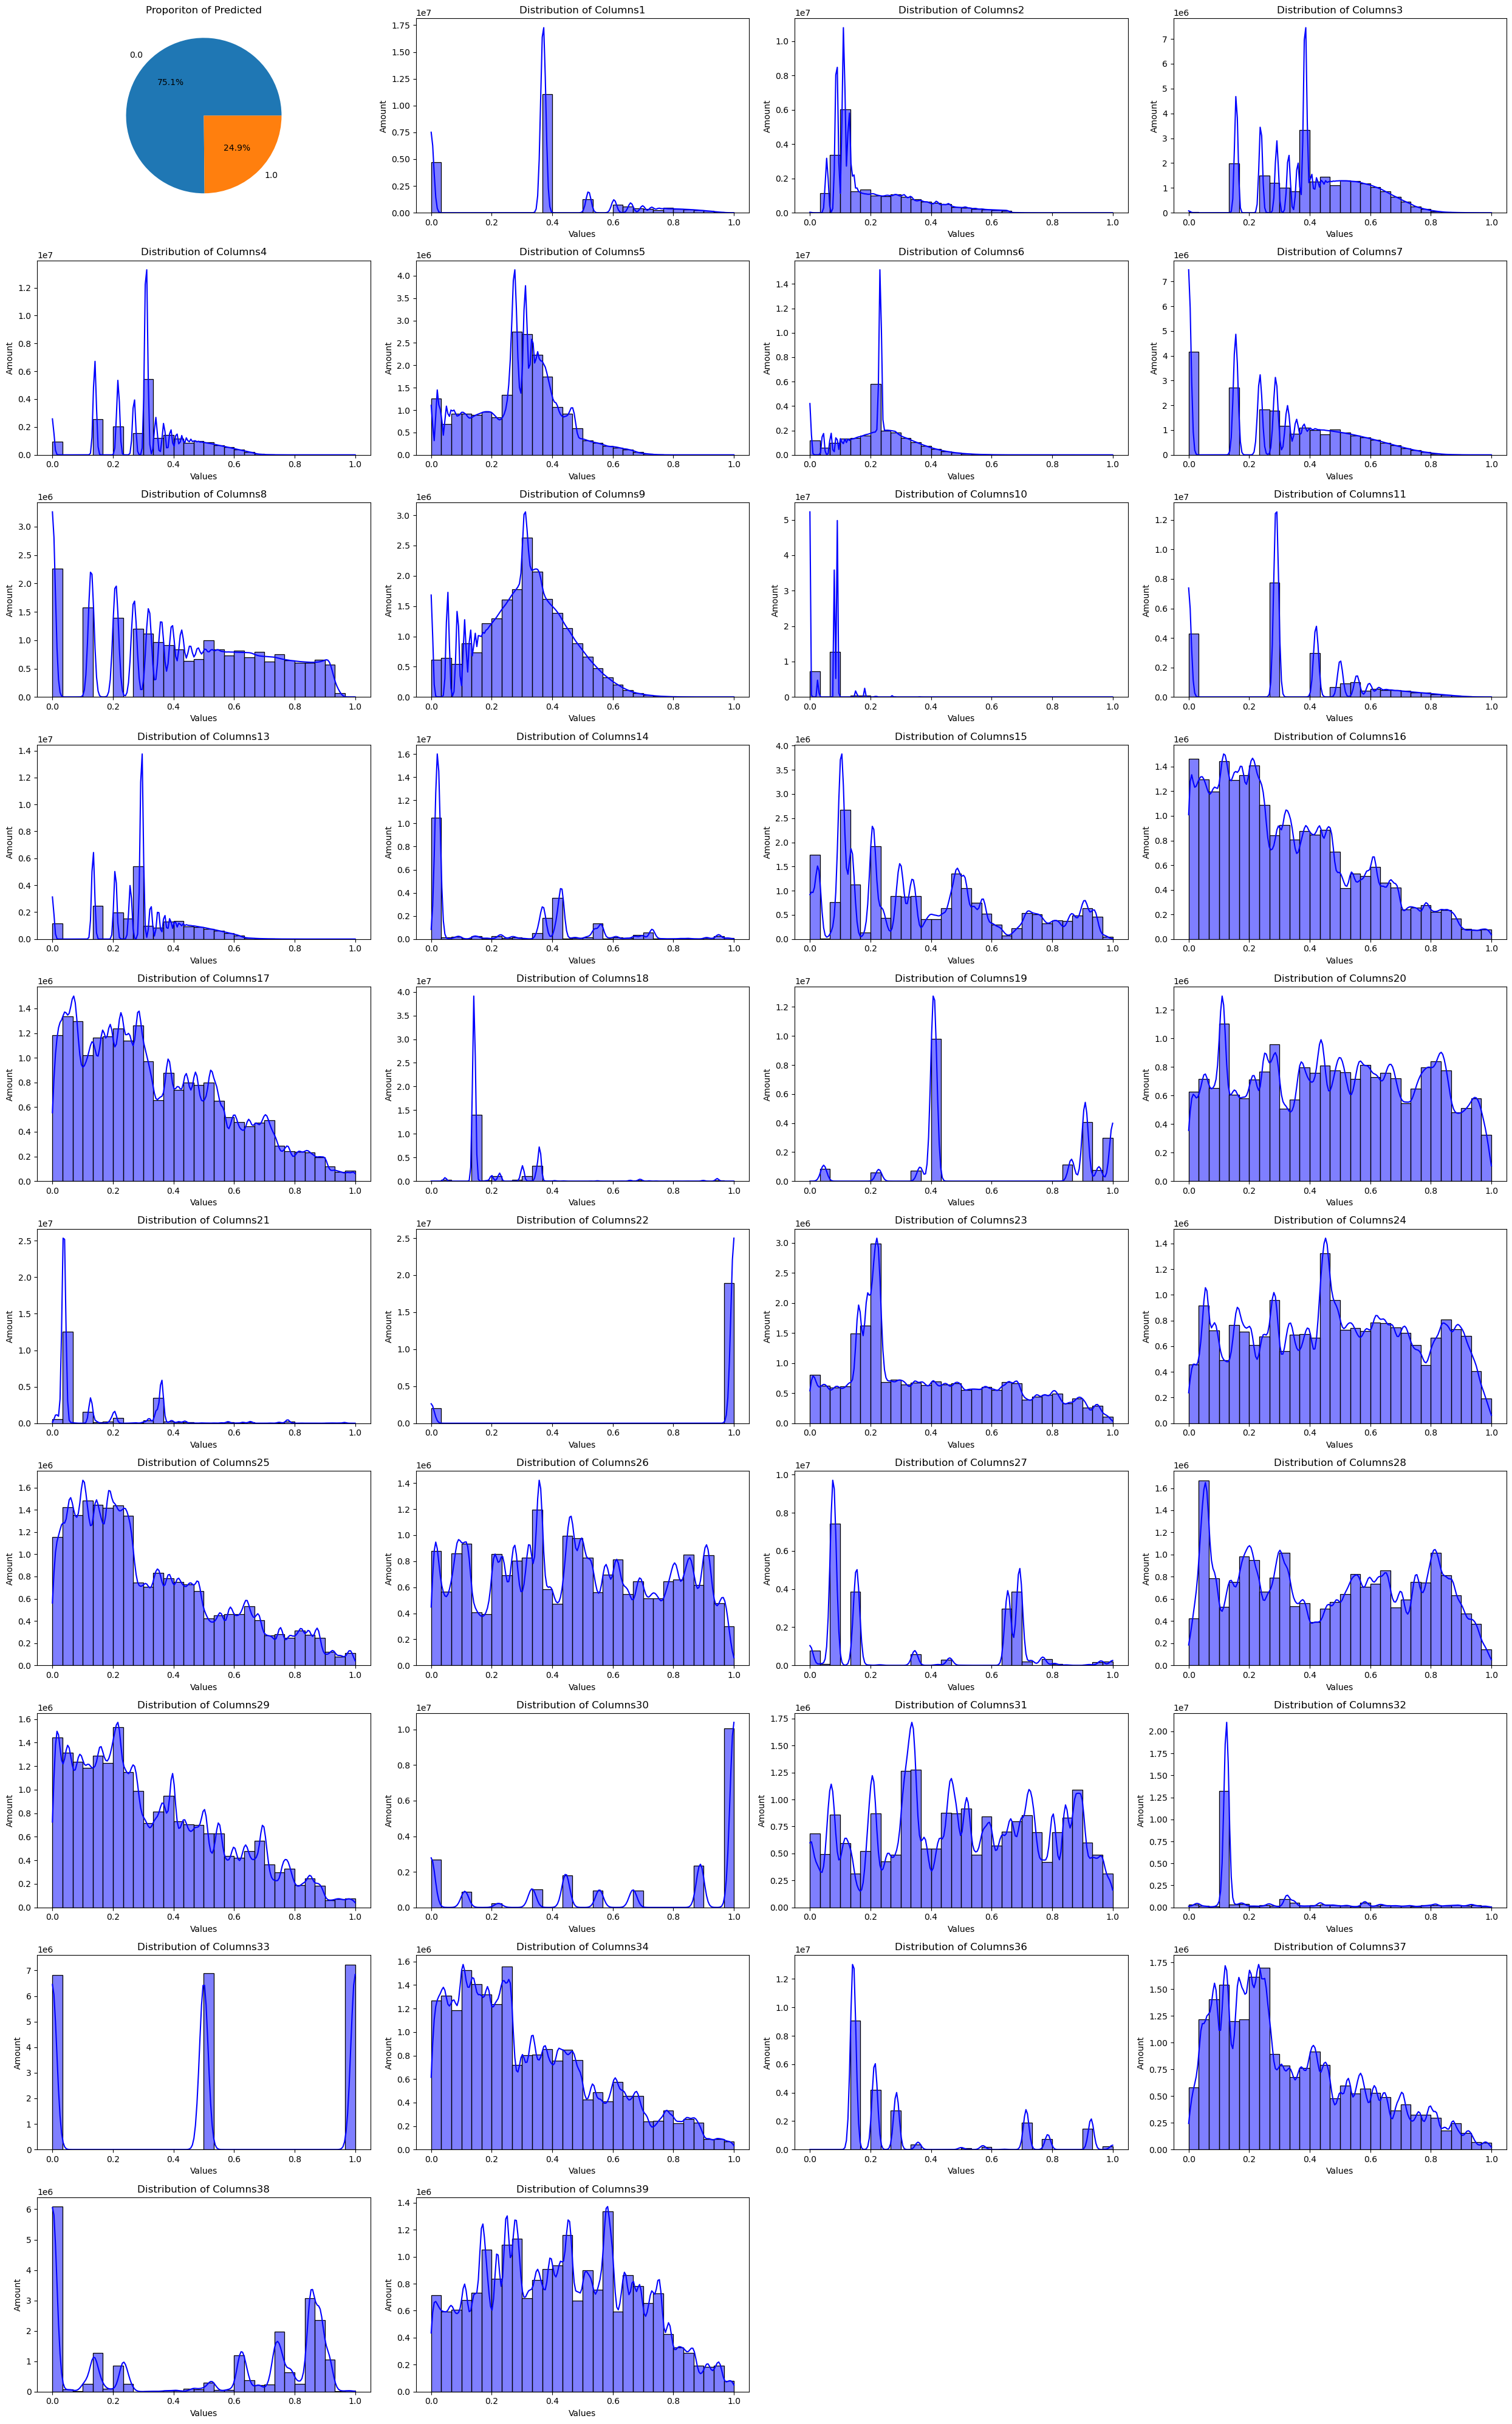

In [20]:
ColumnsHist(train_df)

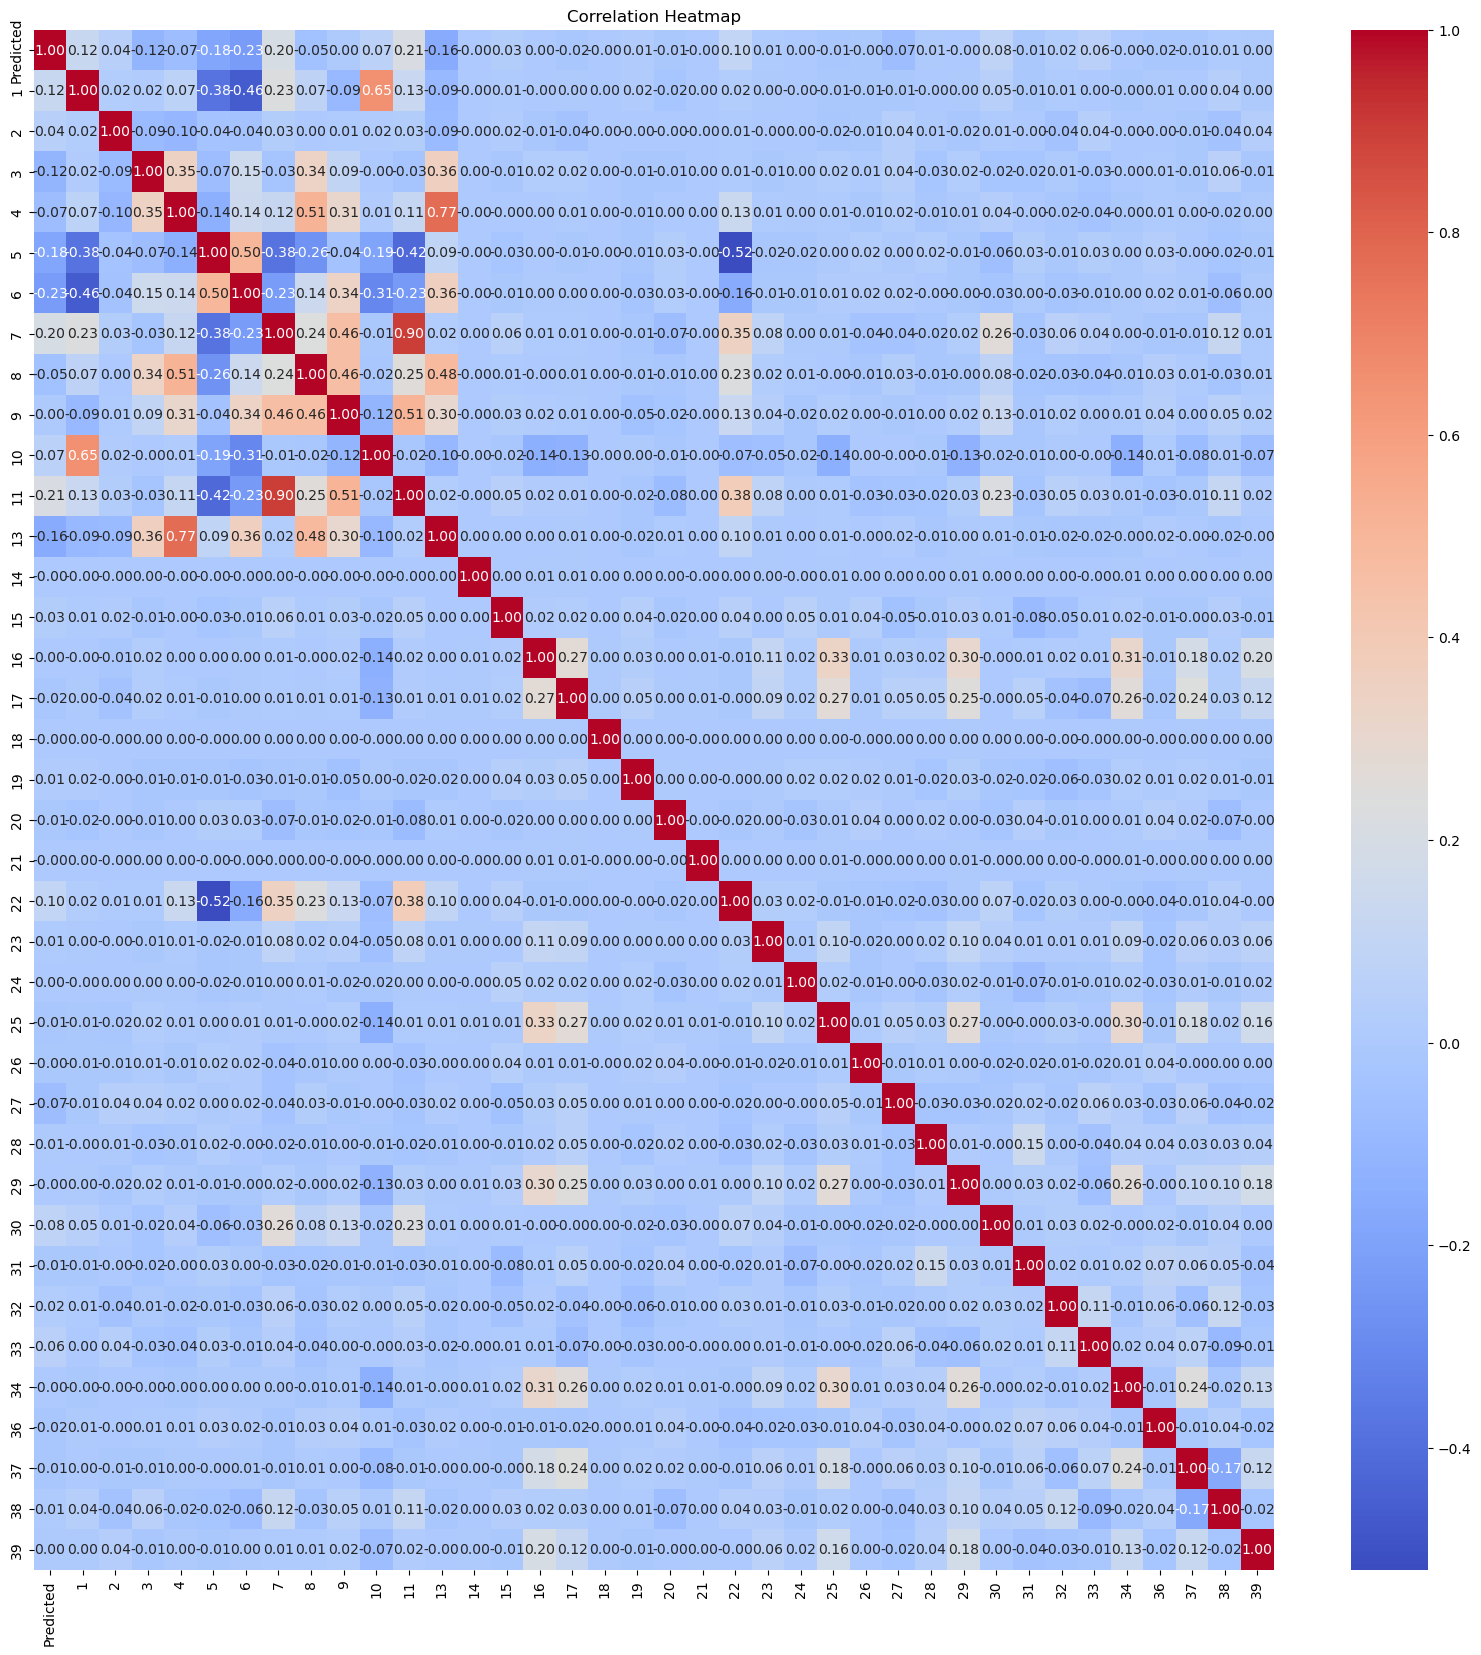

In [73]:
CorrHeatMap(train_df)

#### <span style="color:grey; font-weight:bold;">Correlation</span>

In [21]:
correlation_df = PointBiserialandFilter(train_df, targeted_col='Predicted', threshold=0.05)
correlation_df

Columns: 1, Correlation: 0.12, P-value: 0.00

Columns: 2, Correlation: 0.04, P-value: 0.00

Columns: 3, Correlation: -0.12, P-value: 0.00

Columns: 4, Correlation: -0.07, P-value: 0.00

Columns: 5, Correlation: -0.18, P-value: 0.00

Columns: 6, Correlation: -0.23, P-value: 0.00

Columns: 7, Correlation: 0.20, P-value: 0.00

Columns: 8, Correlation: -0.05, P-value: 0.00

Columns: 9, Correlation: 0.00, P-value: 0.00

Columns: 10, Correlation: 0.07, P-value: 0.00

Columns: 11, Correlation: 0.21, P-value: 0.00

Columns: 13, Correlation: -0.16, P-value: 0.00

Columns: 14, Correlation: -0.00, P-value: 0.48

Columns: 15, Correlation: 0.03, P-value: 0.00

Columns: 16, Correlation: 0.00, P-value: 0.07

Columns: 17, Correlation: -0.02, P-value: 0.00

Columns: 18, Correlation: -0.00, P-value: 0.36

Columns: 19, Correlation: 0.01, P-value: 0.00

Columns: 20, Correlation: -0.01, P-value: 0.00

Columns: 21, Correlation: -0.00, P-value: 0.48

Columns: 22, Correlation: 0.10, P-value: 0.00

Columns: 23

,Predicted,1,3,4,5,6,7,10,11,13,22,27,30,33
0,0.00,0.52,0.62,0.14,0.16,0.14,0.23,0.09,0.29,0.29,1.00,0.65,0.00,0.00
1,0.00,0.37,0.82,0.00,0.50,0.23,0.00,0.09,0.00,0.21,0.00,0.65,0.56,0.00
2,0.00,0.00,0.68,0.31,0.33,0.22,0.15,0.00,0.29,0.29,1.00,0.15,0.44,1.00
3,1.00,0.37,0.38,0.22,0.16,0.07,0.15,0.09,0.29,0.21,1.00,0.08,0.89,1.00
4,0.00,0.00,0.33,0.22,0.30,0.17,0.38,0.00,0.29,0.21,1.00,0.15,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20945512,0.00,0.37,0.56,0.31,0.33,0.23,0.00,0.00,0.00,0.37,1.00,0.69,0.56,0.00
20945513,1.00,0.77,0.61,0.57,0.14,0.27,0.43,0.03,0.43,0.53,1.00,0.69,0.44,0.00
20945514,0.00,0.00,0.64,0.44,0.31,0.23,0.33,0.00,0.29,0.46,1.00,0.08,0.89,0.50
20945515,0.00,0.37,0.39,0.31,0.46,0.24,0.16,0.00,0.29,0.29,0.00,0.15,0.44,0.50


In [22]:
x_train, x_test, y_train, y_test = TestTrainSplit(correlation_df)

In [27]:
SaveCSVNoChunk(x_train, 'X_train')
SaveCSVNoChunk(x_test, 'X_test')
SaveCSVNoChunk(y_train, 'Y_train')
SaveCSVNoChunk(y_test, 'Y_test')

Saved X_train
Saved X_test
Saved Y_train
Saved Y_test
